#Executive Summary

This project creates a clean dataset for Uber ride information in Boston, Massachusetts, intended for civil engineers and urban city planning committees. The goal is to give transportation planners a structured resource they can use to study how ride prices, distances, and demand patterns vary across different parts of the city and at different times of day.

The data comes from a  publicly available Kaggle dataset called "Uber and Lyft Dataset Boston, MA," which includes about 693,000 ride estimates collected across Boston neighborhoods in 2018. Each record includes pickup and drop-off location, ride type  price, distance, and weather conditions. After filtering to Uber only and cleaning the data, the final dataset contains over 300,000 records.

The analysis found that ride type is the biggest driver of price diffrences, with premium options like Black SUV costing noticeably more than economy options like UberX and UberPool. Distance and price had a positive relationship though price per mile helped reveal that shorter trips are often more expensive per mile than longer ones. Surge pricing was rare across the dataset, and weather conditions had only a minor relationship with price.

A major challenge was the original plan to use the Uber API was not possible since Uber shut down public API access around 2019 and 2020. Switching to the Kaggle dataset required extra work to understand its limitations. Building the price per mile and route variables were the most useful parts of the process for making the data ready for planning analysis.

#The "Extra Mile"
The two extra mile points were applied to the bias-related EDA code and bias-related EDA narrative. For the code, we did not just check for missing values. We also wrote additional analysis to look at whether certain ride types or pickup locations showed up more than others in the dataset. For the narrative, we wrote a detailed explanation of every potential bias we found, including missing price data, uneven distributions, and the fact that the dataset only covers a short time period. We also discussed what each of these limitations actually means for someone trying to use this data for real transportation planning decisions.

# Source Details Documentation
## Overview
This project draws from a single Kaggle dataset titled "Uber and Lyft Dataset Boston, MA", published by user brllrb. It can be accessed at the following URL:

https://www.kaggle.com/datasets/brllrb/uber-and-lyft-dataset-boston-ma

##Getting the file.

The source file rideshare_kaggle.csv is downloaded from the Kaggle dataset page at https://www.kaggle.com/datasets/brllrb/uber-and-lyft-dataset-boston-ma. A free Kaggle account is required. After downloading and unzipping the archive, upload rideshare_kaggle.csv to your Colab session or save it to Google Drive.

# Extraction/merging code documentation

#How the Data Was Collected

### Getting the file.
The source file rideshare_kaggle.csv is downloaded from the
Kaggle dataset page at https://www.kaggle.com/datasets/brllrb/uber-and-lyft-dataset-boston-ma.
A free Kaggle account is required.

After clicking "Download" and unzipping the archive, the file should be saved to Google Drive.

Before running any code, Google Drive must be connected to the Colab notebook by running drive.mount(), which prompts the user to sign in and grant access. Once mounted, the full file path, including the Drive mount point, must be provided to locate the file.

<b> Loading the file.</b>

The code reads rideshare_kaggle.csv into Python using pd.read_csv(), a function from the pandas library that loads a comma-separated values (CSV) file into a DataFrame. Each row in the file becomes a row in the table, and each column header becomes a column name. The file contains 693,071 rows and 57 columns covering both Uber and Lyft rides, with ride details and weather conditions already combined into a single table.

<b>Filtering to Uber only.</b>

The cab_type column contains either "Uber" or "Lyft" for each row. Since this project focuses on Uber, we keep only the rows where cab_type equals "Uber". This reduces the dataset to approximately 385,000 rows.

<b>Selecting columns of interest.</b>

Rather than working with all 57 columns, we narrow the table down to the 12 columns relevant to this project: timestamp, source, destination, cab_type, name, distance, price, surge_multiplier, temperature, precipIntensity, cloudCover, and windSpeed. All other columns are discarded at this step.

<b>Converting the timestamp.</b>

The timestamp column stores the date and time as a Unix epoch integer — the number of seconds elapsed since January 1, 1970. This is a standard format for raw API data, but is not human-readable. The code converts it to a standard datetime format using pd.to_datetime() with unit="s", storing the result in a new column called date_time. This makes time-based patterns easier to work with in later analysis steps.




##Variables of Interest
The following variables are retained from the two source files for use in this project.

###From cab_rides.csv:

1. timestamp:

A numeric value representing the exact date and time a ride estimate was recorded. Values are stored in Unix epoch format (seconds since January 1, 1970). In this project, timestamps are converted to a human-readable datetime format and rounded to the nearest hour in order to merge with the hourly weather data.

2. source

The name of the pickup neighborhood in Boston where the ride originates. Values are categorical strings representing specific Boston neighborhoods (e.g., "Back Bay", "Beacon Hill", "Haymarket Square"). There are a small number of distinct locations because the data were collected at a fixed set of high-traffic areas.

3. destination

The name of the drop-off neighborhood in Boston where the ride ends. Same set of categorical string values as source.

4. cab_type

Indicates whether the ride is an Uber or Lyft service. Values are the categorical strings "Uber" or "Lyft". This project filters to "Uber" only.

5. name

The specific Uber ride tier or product type. Categorical string values include ride options such as "UberX", "UberXL", "Black", "Black SUV", and "UberPool". This variable distinguishes between economy, standard, and premium ride options.

6. distance

The estimated trip distance between the source and destination, measured in miles. Numeric (decimal) values.

7. price

 The estimated fare for the ride in US dollars at the time of the query. Numeric (decimal) values. This reflects dynamic pricing; the price may vary based on demand, time of day, and surge conditions. Some rows contain missing price values, which are addressed during cleaning.

8. surge_multiplier

A numeric multiplier representing the degree of surge pricing active at the time of the query. A value of 1.0 indicates no surge. Values greater than 1.0 (e.g., 1.25, 1.5, 2.0) indicate that the base fare was multiplied by that factor due to high demand. For Uber rides in this dataset, this value is typically 1.0 since Uber had largely moved to upfront pricing by 2018.

###From weather.csv

9. temperature

The temperature at the pickup location at the time of the ride, in degrees Fahrenheit. Numeric (decimal) values.

10. precipIntensity

precipitation intensity in inches per hour (not total rainfall), so it captures light drizzle vs heavy rain on a continuous scale

11. cloudCover

A numeric value representing cloud cover at the pickup location, expressed as a proportion between 0 (clear sky) and 1 (fully overcast).

12. windSpeed

Wind speed at the pickup location at the time of the ride, measured in miles per hour. Numeric (decimal) values.

#Extraction code

In [ ]:
from google.colab import drive
drive.mount('/INST447')

Drive already mounted at /INST447; to attempt to forcibly remount, call drive.mount("/INST447", force_remount=True).


In [ ]:
import pandas as pd

# --- Step 1: Load the source file ---
df = pd.read_csv("/INST447/MyDrive/INST447/rideshare_kaggle.csv")

# --- Step 2: Filter to Uber rides only ---
df = df[df["cab_type"] == "Uber"]

# --- Step 3: Select only columns of interest ---
df = df[[
    "timestamp", "source", "destination",
    "cab_type", "name", "distance",
    "price", "surge_multiplier",
    "temperature", "precipIntensity", "cloudCover", "windSpeed"
]]

# --- Step 4: Convert timestamp to readable datetime ---
df["date_time"] = pd.to_datetime(df["timestamp"], unit="s")

# Preview result
print(df.shape)
df.head()

(385663, 13)


,timestamp,source,destination,cab_type,name,distance,price,surge_multiplier,temperature,precipIntensity,cloudCover,windSpeed,date_time
12,1.543616e+09,North End,West End,Uber,UberXL,1.11,12.0,1.0,40.13,0.0000,1.00,3.38,2018-11-30 22:13:01.178999901
13,1.544698e+09,North End,West End,Uber,Black,1.11,16.0,1.0,20.38,0.0000,0.03,2.94,2018-12-13 10:50:11.013999939
14,1.544729e+09,North End,West End,Uber,UberX,1.11,7.5,1.0,32.85,0.0000,0.64,2.65,2018-12-13 19:15:03.934999943
15,1.545005e+09,North End,West End,Uber,WAV,1.11,7.5,1.0,41.29,0.0567,1.00,8.30,2018-12-16 23:55:11.430000067
16,1.544748e+09,North End,West End,Uber,Black SUV,1.11,26.0,1.0,31.25,0.0000,0.91,2.62,2018-12-14 00:40:07.960999966


#Descriptive EDA Stats

In [ ]:

# Numeric variables
numeric_cols = ["distance", "price", "surge_multiplier",
                "temperature", "precipIntensity", "cloudCover", "windSpeed"]

for col in numeric_cols:
    print(f"=== {col} ===")
    print(f"  Min:     {df[col].min():.4f}")
    print(f"  Max:     {df[col].max():.4f}")
    print(f"  Mean:    {df[col].mean():.4f}")
    print(f"  Median:  {df[col].median():.4f}")
    print(f"  Missing: {df[col].isna().sum()}")
    print()

#  Categorical variables
categorical_cols = ["source", "destination", "name"]

for col in categorical_cols:
    print(f"=== {col} ===")
    print(df[col].value_counts().to_string())
    print()

# Timestamp: unique values summary
print("=== date_time ===")
print(f"  Earliest: {df['date_time'].min()}")
print(f"  Latest:   {df['date_time'].max()}")
print(f"  Missing:  {df['date_time'].isna().sum()}")
print()

#  Relationship: average price by ride type
print("=== Average price by ride type (name) ===")
print(df.groupby("name")["price"].mean().sort_values(ascending=False).to_string())
print()

# Relationship: correlation between distance and price
corr = df["distance"].corr(df["price"])
print(f"=== Correlation between distance and price ===")
print(f"  Pearson r: {corr:.4f}")

=== distance ===
  Min:     0.0200
  Max:     7.8600
  Mean:    2.1914
  Median:  2.1700
  Missing: 0

=== price ===
  Min:     4.5000
  Max:     89.5000
  Mean:    15.7953
  Median:  12.5000
  Missing: 55095

=== surge_multiplier ===
  Min:     1.0000
  Max:     1.0000
  Mean:    1.0000
  Median:  1.0000
  Missing: 0

=== temperature ===
  Min:     18.9100
  Max:     57.2200
  Mean:    39.5748
  Median:  40.4900
  Missing: 0

=== precipIntensity ===
  Min:     0.0000
  Max:     0.1447
  Mean:    0.0090
  Median:  0.0000
  Missing: 0

=== cloudCover ===
  Min:     0.0000
  Max:     1.0000
  Mean:    0.6869
  Median:  0.8200
  Missing: 0

=== windSpeed ===
  Min:     0.4500
  Max:     15.0000
  Mean:    6.1947
  Median:  5.9100
  Missing: 0

=== source ===
source
Financial District         32620
Theatre District           32283
Boston University          32144
North End                  32143
Northeastern University    32142
Fenway                     32137
Back Bay                   32

#Descriptive EDA Visualizations

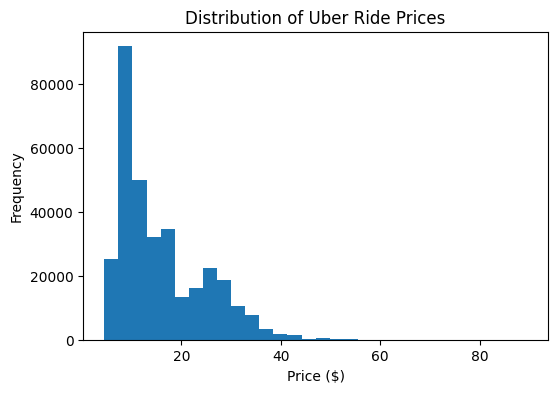

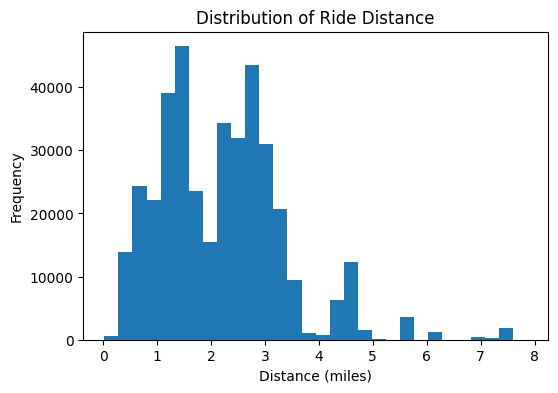

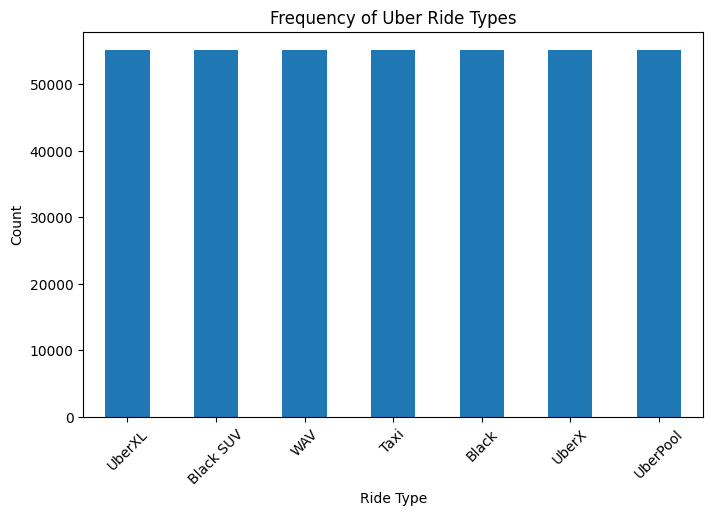

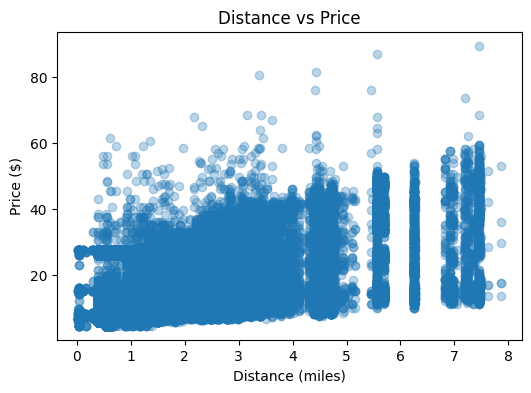

In [ ]:
import matplotlib.pyplot as plt

# Histogram: Uber Ride Prices
plt.figure(figsize=(6,4))

plt.hist(df["price"].dropna(), bins=30)

plt.title("Distribution of Uber Ride Prices")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")

plt.show()

# Histogram: Ride Distance
plt.figure(figsize=(6,4))

plt.hist(df["distance"].dropna(), bins=30)

plt.title("Distribution of Ride Distance")
plt.xlabel("Distance (miles)")
plt.ylabel("Frequency")

plt.show()

# Bar Chart: Uber Ride Types
plt.figure(figsize=(8,5))

df["name"].value_counts().plot(kind="bar")

plt.title("Frequency of Uber Ride Types")
plt.xlabel("Ride Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

# Scatterplot: Distance vs Price
plt.figure(figsize=(6,4))

plt.scatter(
    df["distance"],
    df["price"],
    alpha=0.3
)

plt.title("Distance vs Price")
plt.xlabel("Distance (miles)")
plt.ylabel("Price ($)")

plt.show()

#Descriptive EDA Narrative
The descriptive EDA revealed several important patterns within the Uber ride dataset. The histogram of Uber ride prices showed a right-skewed distribution, meaning that most rides were lower in cost while a smaller number of rides had significantly higher prices. This pattern is expected in urban systems because shorter and lower-cost trips are generally more common than expensive long-distance rides.

The ride distance distribution also showed that most trips were shorter distances, with fewer rides occurring at longer distances. The histogram suggests that urban Uber usage in Boston is primarily concentrated around shorter city travel routes.

The bar chart of Uber ride types showed that the dataset contains a nearly equal number of observations for each ride category. This balanced distribution helps reduce the likelihood that one ride type dominates the dataset and improves the ability to compare pricing patterns between ride categories.

The scatterplot comparing distance and price demonstrated a positive relationship between the two variables. In general, ride prices increased as trip distance increased. However, there was still noticeable variation in prices among rides with similar distances, which may be influenced by factors such as surge pricing, traffic conditions, or ride type differences.

Overall, the descriptive EDA demonstrated that the dataset contains realistic transportation patterns and meaningful relationships between distance and ride pricing, making it useful for studying Uber pricing and urban mobility trends in Boston.

# BIAS-RELATED EDA


=== Missing Values ===
timestamp               0
source                  0
destination             0
cab_type                0
name                    0
distance                0
price               55095
surge_multiplier        0
temperature             0
precipIntensity         0
cloudCover              0
windSpeed               0
date_time               0
dtype: int64

=== Ride Type Distribution ===
name
UberXL       14.29
Black SUV    14.29
WAV          14.29
Taxi         14.29
Black        14.29
UberX        14.29
UberPool     14.28

=== Pickup Location Distribution ===
source
Financial District         8.46
Theatre District           8.37
Boston University          8.33
North End                  8.33
Northeastern University    8.33
Fenway                     8.33
Back Bay                   8.33
South Station              8.33
Haymarket Square           8.33
West End                   8.32
Beacon Hill                8.28
North Station              8.24


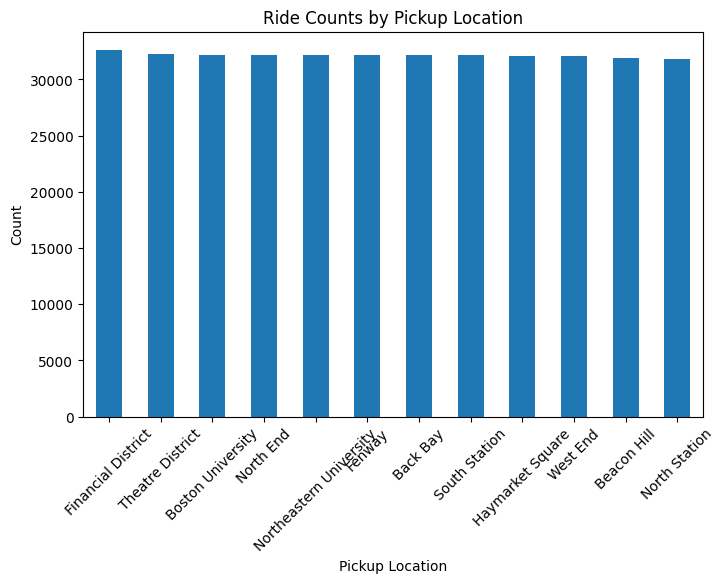

In [ ]:
# Missing Value Analysis
print("=== Missing Values ===")
print(df.isna().sum())

# Ride Type Distribution
print("\n=== Ride Type Distribution ===")

print((df["name"].value_counts(normalize=True) * 100).round(2).to_string())

# Pickup Location Distribution
print("\n=== Pickup Location Distribution ===")

print((df["source"].value_counts(normalize=True) * 100).round(2).to_string())

# Visualization: Pickup Location Counts
plt.figure(figsize=(8,5))

df["source"].value_counts().plot(kind="bar")

plt.title("Ride Counts by Pickup Location")
plt.xlabel("Pickup Location")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

#Bias-Related EDA Narrative
The bias-related EDA identified several potential limitations within the Uber ride dataset. The most significant issue was the large number of missing values in the price variable. Since price is one of the most important variables in the project, these missing values could affect analyses related to ride costs, pricing trends, or comparisons between ride types. To reduce this issue, rows with missing prices were removed during the transformation process.

The distributions of ride types and pickup locations appeared relatively balanced across the dataset. Each ride type represented a similar percentage of the observations, and pickup locations were also distributed fairly evenly across Boston neighborhoods. This suggests that no single location heavily dominated the dataset.

Another possible limitation is temporal bias. The dataset represents rides collected during a limited period of time rather than across multiple years or seasons. Uber ride behavior may change depending on weather conditions, holidays, tourism, traffic patterns, or major city events. Because of this, the dataset may not fully capture long-term transportation trends in Boston.

Overall, while the dataset is generally balanced and suitable for analysis, the missing price values and limited time range should still be considered when interpreting the results.

# Transformation Processes




## Transformation Documentation


For the final data product, we reshaped and cleaned the Uber ride data, making it easier for us for users to be able to analyze the ride prices. We first removed the rows that had `price` missing because price is one of the most valuable variables for our project. We also removed rows that had duplicates, so the final data set would not calculate the same ride estimate multiple times. Our next step was to create new time based variables from `date_time`, that included `hour`, `day_of_week`, and `month`. This all made it simpler for us to study the pricing by day of the week or time of day without needing to work with the full timestamp. We also created a new variable called `route`, which added the destination and pickup location together. This benefited the users to be able to compare the Uber routes in Boston. Our final step was to create `price_per_mile` that divided the price by distance. This made the comparison easy for short vs long rides and the prices for them. The final data product kept only columns that were most useful to analyze the Uber ride cost, weather conditions, surge pricing, distance, ride type, and location.






## Transformation Code


In [ ]:
# Make a copy so the original extracted data stays unchanged
uber_clean = df.copy()

# Remove rows with missing prices
uber_clean = uber_clean.dropna(subset=["price"])

# Remove duplicate rows
uber_clean = uber_clean.drop_duplicates()

# Create useful time variables
uber_clean["hour"] = uber_clean["date_time"].dt.hour
uber_clean["day_of_week"] = uber_clean["date_time"].dt.day_name()
uber_clean["month"] = uber_clean["date_time"].dt.month_name()

# Create route variable
uber_clean["route"] = uber_clean["source"] + " to " + uber_clean["destination"]

# Create price per mile
uber_clean["price_per_mile"] = uber_clean["price"] / uber_clean["distance"]

# Remove extreme values caused by distance issues
uber_clean = uber_clean[uber_clean["distance"] > 0]

# Select final columns for data product
final_uber_data = uber_clean[[
    "date_time",
    "hour",
    "day_of_week",
    "month",
    "source",
    "destination",
    "route",
    "cab_type",
    "name",
    "distance",
    "price",
    "price_per_mile",
    "surge_multiplier",
    "temperature",
    "precipIntensity",
    "cloudCover",
    "windSpeed"
]]

# Preview final transformed data
print(final_uber_data.shape)
final_uber_data.head()

(329773, 17)


,date_time,hour,day_of_week,month,source,destination,route,cab_type,name,distance,price,price_per_mile,surge_multiplier,temperature,precipIntensity,cloudCover,windSpeed
12,2018-11-30 22:13:01.178999901,22,Friday,November,North End,West End,North End to West End,Uber,UberXL,1.11,12.0,10.810811,1.0,40.13,0.0000,1.00,3.38
13,2018-12-13 10:50:11.013999939,10,Thursday,December,North End,West End,North End to West End,Uber,Black,1.11,16.0,14.414414,1.0,20.38,0.0000,0.03,2.94
14,2018-12-13 19:15:03.934999943,19,Thursday,December,North End,West End,North End to West End,Uber,UberX,1.11,7.5,6.756757,1.0,32.85,0.0000,0.64,2.65
15,2018-12-16 23:55:11.430000067,23,Sunday,December,North End,West End,North End to West End,Uber,WAV,1.11,7.5,6.756757,1.0,41.29,0.0567,1.00,8.30
16,2018-12-14 00:40:07.960999966,0,Friday,December,North End,West End,North End to West End,Uber,Black SUV,1.11,26.0,23.423423,1.0,31.25,0.0000,0.91,2.62


# Data Product & Guide



## Data Product Description

The final data product is a CSV file that is cleaned, called `final_uber_boston_data.csv`. It is designed for people like students, researchers, etc that want to study Uber ride prices in Boston. The file has information on only Uber rides and the ride details, route information, pricing variables, and weather conditions.

##Variables Guide

- `cab_type`: Company for ride.
- `name`: Uber ride type.
- `distance`: Estimated trip distance in miles.
- `price`: Estimated Uber cost in dollars.
- `price_per_mile`: Cost per mile of the trip.
- `surge_multiplier`: Shows if Uber prices were increased because of high demand. A value of 1.0 means the normal price.
- `temperature`: Temperature during the ride estimate.
- `precipIntensity`: Total precipitation.
- `cloudCover`: Cloud cover describes how much of the sky is covered by clouds.
- `windSpeed`: Wind speed during the time of ride estimate.
- `date_time`: Time and date of ride estimate were recorded.
- `hour`: Timestamps the hour of the day
- `day_of_week`: Day of the week.
- `month`: Month of the ride estimate.
- `source`: Pickup location in Boston.
- `destination`: Drop-off location in Boston.
- `route`: Combined pickup and drop-off route.


## User Guide

To use the final data product, download and then open the CSV file named `final_uber_boston_data.csv`. Users can either load it with Excel, Tableau, Python, or Google Sheets. Using Python, it can be opened with `pd.read_csv()`.

This dataset can answer questions, for example:
- Which routes have higher average prices?
- Do weather conditions have a connection to higher ride costs?
- Does distance affect the price? Why or why not?
- Does surge pricing increase prices?
- Which Uber ride types are most expensive?




##Data Product Code


In [ ]:

# We define final_uber_data here to ensure the variable exists when saving
final_uber_data = uber_clean[[
    "date_time",
    "hour",
    "day_of_week",
    "month",
    "source",
    "destination",
    "route",
    "cab_type",
    "name",
    "distance",
    "price",
    "price_per_mile",
    "surge_multiplier",
    "temperature",
    "precipIntensity",
    "cloudCover",
    "windSpeed"
]]

# export the data product
final_uber_data.to_csv("final_uber_boston_data.csv", index=False)

print("The data product 'final_uber_boston_data.csv' has been created successfully.")

The data product 'final_uber_boston_data.csv' has been created successfully.


##Data Product Implementation

This final section of the code generates the actual deliverable for the project: the `final_uber_boston_data.csv` file.

By using the `to_csv()` function on our `final_uber_data` DataFrame, we are packaging all the cleaning and feature engineering work—such as the calculated `price_per_mile` and the combined route strings—into a portable format. This file allows urban planners and researchers to perform their own analyses on Uber pricing and transit patterns in Boston without
needing to re-run the complex cleaning scripts.